In [6]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [27]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    'data/validation',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f"Nombre d'images train : {train_generator.samples}")
print(f"Nombre d'images validation : {val_generator.samples}")

print(train_generator.class_indices)
print(train_generator.num_classes)


Found 5249 images belonging to 7 classes.
Found 1309 images belonging to 7 classes.
Nombre d'images train : 5249
Nombre d'images validation : 1309
{'peach_bacterial spot': 0, 'peach_healthy': 1, 'pepper-bell_bacterial spot': 2, 'pepper-bell_healthy': 3, 'potato_early blight': 4, 'potato_healthy': 5, 'potato_late blight': 6}
7


In [30]:
def create_deep_cnn(input_shape=(128,128,3), num_classes=7):
    model = keras.Sequential([
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape,padding='same'),
        layers.MaxPooling2D(2, 2),
        
        layers.Dropout(0.25),
        
        layers.Conv2D(32, (3, 3), activation='relu',padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    return model

model_cnn = create_deep_cnn()
model_cnn.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 128, 128, 16)      448       
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 64, 64, 16)        0         
 ng2D)                                                           
                                                                 
 dropout_19 (Dropout)        (None, 64, 64, 16)        0         
                                                                 
 conv2d_16 (Conv2D)          (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 32, 32, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_20 (Dropout)        (None, 32, 32, 32)       

In [31]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [33]:
history = model_cnn.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)


Epoch 1/30
165/165 [==============================] - 75s 454ms/step - loss: 0.2925 - accuracy: 0.8988 - val_loss: 0.2613 - val_accuracy: 0.9099 - lr: 5.0000e-04
Epoch 2/30
165/165 [==============================] - 56s 339ms/step - loss: 0.2800 - accuracy: 0.9059 - val_loss: 0.2202 - val_accuracy: 0.9236 - lr: 5.0000e-04
Epoch 3/30
165/165 [==============================] - 40s 242ms/step - loss: 0.2656 - accuracy: 0.9116 - val_loss: 0.2345 - val_accuracy: 0.9167 - lr: 5.0000e-04
Epoch 4/30
165/165 [==============================] - 40s 241ms/step - loss: 0.2666 - accuracy: 0.9097 - val_loss: 0.1854 - val_accuracy: 0.9412 - lr: 5.0000e-04
Epoch 5/30
165/165 [==============================] - 41s 246ms/step - loss: 0.2500 - accuracy: 0.9173 - val_loss: 0.1685 - val_accuracy: 0.9481 - lr: 5.0000e-04
Epoch 6/30
165/165 [==============================] - 40s 243ms/step - loss: 0.2491 - accuracy: 0.9152 - val_loss: 0.2505 - val_accuracy: 0.9152 - lr: 5.0000e-04
Epoch 7/30
165/165 [========

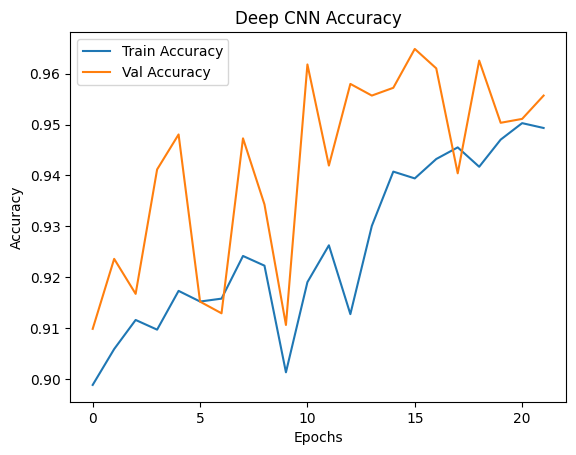

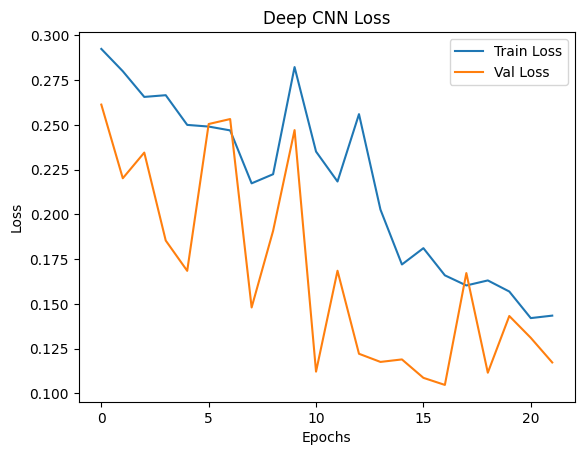

In [34]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Deep CNN Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Deep CNN Loss')
plt.show()


In [35]:
model_cnn.save('models/deep_cnn.h5')
print("Modèle Deep CNN sauvegardé !")


c:\Users\PC\OneDrive\Documents\Master\Master 2\Python for Data\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Modèle Deep CNN sauvegardé !
